In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
dfins = pd.read_csv(r"D:\DATASETS\Regression Data sets\insurance.csv")

In [6]:
dfins

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### NaNs

In [7]:
dfins.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
dfins.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Error Detection

In [9]:
dfins.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [10]:
dfins["sex"]

0       female
1         male
2         male
3         male
4         male
         ...  
1333      male
1334    female
1335    female
1336    female
1337    female
Name: sex, Length: 1338, dtype: object

In [11]:
dfins["sex"].unique()

array(['female', 'male'], dtype=object)

In [12]:
dfins["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [13]:
dfins["smoker"]

0       yes
1        no
2        no
3        no
4        no
       ... 
1333     no
1334     no
1335     no
1336     no
1337    yes
Name: smoker, Length: 1338, dtype: object

In [14]:
dfins["smoker"].unique()

array(['yes', 'no'], dtype=object)

In [15]:
dfins["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [16]:
dfins["region"]

0       southwest
1       southeast
2       southeast
3       northwest
4       northwest
          ...    
1333    northwest
1334    northeast
1335    southeast
1336    southwest
1337    northwest
Name: region, Length: 1338, dtype: object

In [17]:
dfins["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [18]:
dfins["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [19]:
dfins.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: >

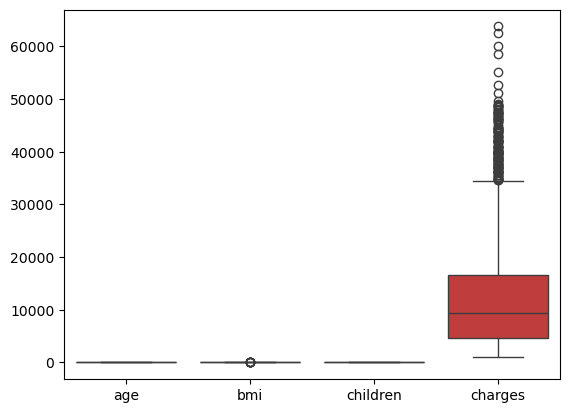

In [20]:
sns.boxplot(dfins)

<Axes: ylabel='bmi'>

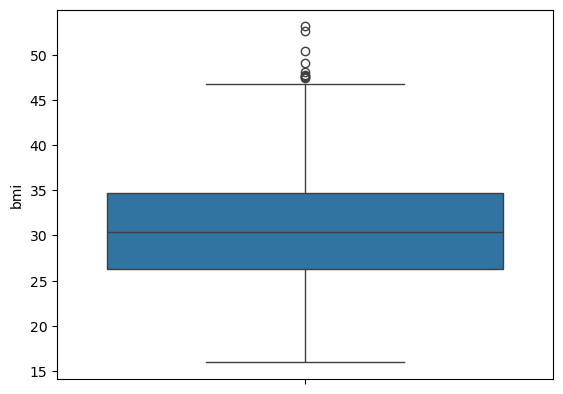

In [21]:
sns.boxplot(dfins["bmi"])

<Axes: ylabel='charges'>

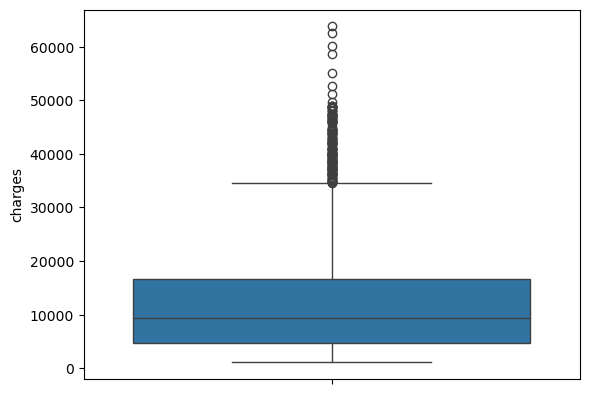

In [22]:
sns.boxplot(dfins["charges"] )

In [23]:
dfins.shape

(1338, 7)

### BMI Error Detection

In [24]:
q1 = dfins["bmi"].quantile(0.25)

In [25]:
q3 = dfins["bmi"].quantile(0.75)

In [26]:
q1

np.float64(26.29625)

In [27]:
q3

np.float64(34.69375)

In [28]:
dfins["bmi"].describe()

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

In [29]:
iqr = q3 - q1

In [30]:
iqr

np.float64(8.3975)

In [31]:
lowerlimit = q1 - (1.5 * iqr)

In [32]:
lowerlimit

np.float64(13.7)

In [33]:
upperlimit = q3 + (1.5 * iqr)

In [34]:
upperlimit

np.float64(47.290000000000006)

In [35]:
dfins[(dfins["bmi"] < lowerlimit) | (dfins["bmi"] > upperlimit)]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.32540
286,46,female,48.07,2,no,northeast,9432.92530
401,47,male,47.52,1,no,southeast,8083.91980
543,54,female,47.41,0,yes,southeast,63770.42801
847,23,male,50.38,1,no,southeast,2438.05520
860,37,female,47.60,2,yes,southwest,46113.51100
1047,22,male,52.58,1,yes,southeast,44501.39820
1088,52,male,47.74,1,no,southeast,9748.91060
1317,18,male,53.13,0,no,southeast,1163.46270


In [36]:
dfins[(dfins["bmi"] < lowerlimit) | (dfins["bmi"] > upperlimit)].count()

age         9
sex         9
bmi         9
children    9
smoker      9
region      9
charges     9
dtype: int64

### Capping

In [37]:
dfins["bmi"].map(lambda x :  lowerlimit if x < lowerlimit  else  upperlimit if x > upperlimit else x)

0       27.900
1       33.770
2       33.000
3       22.705
4       28.880
         ...  
1333    30.970
1334    31.920
1335    36.850
1336    25.800
1337    29.070
Name: bmi, Length: 1338, dtype: float64

In [38]:
dfins["bmi"] = dfins["bmi"].map(lambda x :  lowerlimit if x < lowerlimit  else  upperlimit if x > upperlimit else x)

<Axes: ylabel='bmi'>

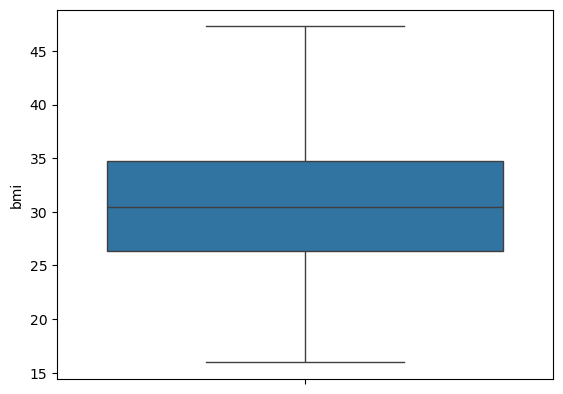

In [39]:
sns.boxplot(dfins["bmi"])

### Encoding

In [40]:
dfins.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [41]:
dfins.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [42]:
dfins["sex"].unique()

array(['female', 'male'], dtype=object)

In [43]:
dfins["smoker"].unique()

array(['yes', 'no'], dtype=object)

In [44]:
dfins["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [45]:
pd.get_dummies(dfins)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False,True,True,False,False,True,False,False
1334,18,31.920,0,2205.98080,True,False,True,False,True,False,False,False
1335,18,36.850,0,1629.83350,True,False,True,False,False,False,True,False
1336,21,25.800,0,2007.94500,True,False,True,False,False,False,False,True


In [46]:
dfins = pd.get_dummies(dfins)

In [47]:
dfins

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False,True,True,False,False,True,False,False
1334,18,31.920,0,2205.98080,True,False,True,False,True,False,False,False
1335,18,36.850,0,1629.83350,True,False,True,False,False,False,True,False
1336,21,25.800,0,2007.94500,True,False,True,False,False,False,False,True


In [48]:
dfins.replace([True, False], [1, 0])

C:\Users\user\AppData\Local\Temp\ipykernel_12764\2181345603.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfins.replace([True, False], [1, 0])


,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0,1,1,0,0,1,0,0
1334,18,31.920,0,2205.98080,1,0,1,0,1,0,0,0
1335,18,36.850,0,1629.83350,1,0,1,0,0,0,1,0
1336,21,25.800,0,2007.94500,1,0,1,0,0,0,0,1


In [49]:
dfins.replace([True, False], [1, 0], inplace= True)

C:\Users\user\AppData\Local\Temp\ipykernel_12764\900276993.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfins.replace([True, False], [1, 0], inplace= True)


In [50]:
dfins

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0,1,1,0,0,1,0,0
1334,18,31.920,0,2205.98080,1,0,1,0,1,0,0,0
1335,18,36.850,0,1629.83350,1,0,1,0,0,0,1,0
1336,21,25.800,0,2007.94500,1,0,1,0,0,0,0,1


### Data Separation

In [51]:
dfins.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


In [52]:
dfins.drop("charges", axis = 1)

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,0
2,28,33.000,3,0,1,1,0,0,0,1,0
3,33,22.705,0,0,1,1,0,0,1,0,0
4,32,28.880,0,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,0,1,1,0,0,1,0,0
1334,18,31.920,0,1,0,1,0,1,0,0,0
1335,18,36.850,0,1,0,1,0,0,0,1,0
1336,21,25.800,0,1,0,1,0,0,0,0,1


In [53]:
X = dfins.drop("charges", axis = 1)

In [54]:
X.shape

(1338, 11)

In [55]:
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,0
2,28,33.000,3,0,1,1,0,0,0,1,0
3,33,22.705,0,0,1,1,0,0,1,0,0
4,32,28.880,0,0,1,1,0,0,1,0,0


In [56]:
y = dfins["charges"]

In [57]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

### Splitting 

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2 )

In [60]:
X_train.shape

(1070, 11)

In [61]:
X_test.shape

(268, 11)

In [62]:
X.shape

(1338, 11)

### Linear Regression Model

In [63]:
from sklearn.linear_model import LinearRegression

In [64]:
lr_model = LinearRegression()

In [65]:
lr_model

LinearRegression()

In [66]:
lr_model.fit(X_train, y_train)

LinearRegression()

In [67]:
lr_model.coef_

array([   251.01347108,    333.96619348,    587.41427332,     16.11487   ,
          -16.11487   , -11958.92311442,  11958.92311442,    526.17621102,
          147.16330212,   -250.79542308,   -422.54409006])

In [68]:
lr_model.intercept_

np.float64(-370.6049209577668)

In [69]:
lr_model.score(X_test, y_test)

0.7457199654909238

### Auto Random State

In [70]:
score = []
for i in range(1, 500):
    Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.20, random_state= i)
    linreg = LinearRegression()
    linreg.fit(Xtrain, ytrain)
    sc = linreg.score(Xtest, ytest)
    score.append(sc)

m = max(score)
rs = score.index(m)
print("Maximum Score", m)
print("Best Random State", rs)

Maximum Score 0.8331309092720207
Best Random State 366


### Auto ML

In [71]:
from sklearn.model_selection import train_test_split

In [76]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.20, random_state= 367)

In [77]:
lr_model = LinearRegression()

In [78]:
lr_model.fit(Xtrain, ytrain)

LinearRegression()

In [79]:
lr_model.score(Xtest, ytest)

0.8331309092720207

### Prediction

In [116]:
lr_model

LinearRegression()

In [117]:
dfins.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


In [118]:
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,0
2,28,33.000,3,0,1,1,0,0,0,1,0
3,33,22.705,0,0,1,1,0,0,1,0,0
4,32,28.880,0,0,1,1,0,0,1,0,0


In [ ]:
[[28, 33.000, 3, 0, 1, 1, 0, 0, 0, 1, 0]]

In [119]:
lr_model.predict([[28, 33.000, 3, 0, 1, 1, 0, 0, 0, 1, 0]])

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([6937.32420774])

### Auto ML

In [80]:
from sklearn.tree import DecisionTreeRegressor

In [82]:
from sklearn.ensemble import RandomForestRegressor

In [83]:
from sklearn.svm import SVR

In [84]:
from sklearn.ensemble import AdaBoostRegressor

In [85]:
from sklearn.neighbors import KNeighborsRegressor

In [86]:
dt1 = DecisionTreeRegressor()

In [87]:
rfc1 = RandomForestRegressor()

In [88]:
svm1 = SVR()

In [89]:
ada1 = AdaBoostRegressor()

In [90]:
knn1 = KNeighborsRegressor()

In [91]:
lr1 = LinearRegression()

In [92]:
models = [dt1, rfc1, svm1, ada1, knn1, lr1]

In [93]:
models

[DecisionTreeRegressor(),
 RandomForestRegressor(),
 SVR(),
 AdaBoostRegressor(),
 KNeighborsRegressor(),
 LinearRegression()]

In [94]:
import time

In [95]:
for m in models: 
    print(m)
    time.sleep(1)

DecisionTreeRegressor()
RandomForestRegressor()
SVR()
AdaBoostRegressor()
KNeighborsRegressor()
LinearRegression()


In [96]:
for m in models : 
    m.fit(Xtrain, ytrain)
    s = m.score(Xtest, ytest)
    print(m, "==>", s)
    time.sleep(1)

DecisionTreeRegressor() ==> 0.693800131275467
RandomForestRegressor() ==> 0.8886220187188896
SVR() ==> -0.11556441633139536
AdaBoostRegressor() ==> 0.8539105873502323
KNeighborsRegressor() ==> 0.25934535949044435
LinearRegression() ==> 0.8331309092720207


### Cross Validation

In [97]:
from sklearn.model_selection import cross_val_score

In [98]:
rfc2 = RandomForestRegressor()

In [99]:
scores = cross_val_score(rfc2, X, y, cv = 10, n_jobs = -1)

In [100]:
scores

array([0.86872163, 0.83569656, 0.82250349, 0.73034752, 0.85674633,
       0.89503619, 0.84818871, 0.79682713, 0.84525447, 0.86324776])

In [101]:
scores.mean()

np.float64(0.8362569788274268)

In [102]:
rfc3 = RandomForestRegressor()

In [103]:
scores20 = cross_val_score(rfc3, X, y, cv = 20, n_jobs = -1)
scores20

array([0.87868742, 0.84711402, 0.83205908, 0.82091437, 0.87893427,
       0.68686256, 0.74037818, 0.7403956 , 0.8184058 , 0.87679265,
       0.86418016, 0.93775974, 0.88335086, 0.80695804, 0.76204249,
       0.8121478 , 0.85183098, 0.83883753, 0.82911858, 0.89583896])

In [104]:
scores20.mean()

np.float64(0.8301304534048173)

### Auto ML with Cross Validation

In [106]:
dtr = DecisionTreeRegressor() 

In [107]:
rfr = RandomForestRegressor()

In [108]:
svr = SVR()

In [109]:
adar = AdaBoostRegressor()

In [110]:
knnr = KNeighborsRegressor()

In [111]:
lreg = LinearRegression()

In [112]:
model = [dtr, rfr, svr, adar, knnr, lreg]

In [113]:
model

[DecisionTreeRegressor(),
 RandomForestRegressor(),
 SVR(),
 AdaBoostRegressor(),
 KNeighborsRegressor(),
 LinearRegression()]

In [114]:
for m in model : 
    print(m)
    time.sleep(1)

DecisionTreeRegressor()
RandomForestRegressor()
SVR()
AdaBoostRegressor()
KNeighborsRegressor()
LinearRegression()


In [115]:
for m in model :
    sc = cross_val_score(m, X, y, cv = 20, n_jobs= -2)
    print(m)
    print()
    print(sc)
    print()
    print(sc.mean())
    print()
    print("****************************")

DecisionTreeRegressor()

[0.82362535 0.65199728 0.70395906 0.76585558 0.77543657 0.52751701
 0.55917338 0.65175484 0.72538782 0.75451452 0.67571012 0.82364725
 0.77052837 0.73055261 0.52333595 0.7366401  0.66294414 0.73921905
 0.71002004 0.71141377]

0.7011616401165223

****************************
RandomForestRegressor()

[0.87731938 0.84891704 0.82847301 0.82665717 0.88057824 0.68250546
 0.73166684 0.7348548  0.82915806 0.8857518  0.87164532 0.93906786
 0.87810779 0.81671709 0.75645632 0.81556168 0.85220171 0.8379338
 0.82364447 0.90042073]

0.8308819277265295

****************************
SVR()

[-0.15107454 -0.11726671 -0.01665279 -0.22659507 -0.21425542 -0.07914746
 -0.06935315 -0.06732285 -0.05010259 -0.19883857 -0.0545706  -0.06559631
 -0.10139117 -0.04790075 -0.08166349 -0.23145073 -0.16942992 -0.0632411
 -0.09195597 -0.11637985]

-0.11070945290126719

****************************
AdaBoostRegressor()

[0.86618341 0.78488283 0.79907372 0.83156698 0.8629682  0.71999084
 0.7501729